In [ ]:
import json
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

def visualize_failed_cases(json_path, image_base_path):
    with open(json_path, "r") as f:
        failed_cases = json.load(f)

    for idx, case in enumerate(failed_cases):
        img_path = os.path.join(image_base_path, case["image_path"])  # Adjust image_base_path
        try:
            img = Image.open(img_path)
        except FileNotFoundError:
            print(f"Image not found: {img_path}")
            continue

        fig, ax = plt.subplots(1)
        ax.imshow(img)

        # Draw ground truth bbox
        if case["gt_bbox"]:
            gt_bbox = case["gt_bbox"]
            rect = patches.Rectangle(
                (gt_bbox[0], gt_bbox[1]),
                gt_bbox[2] - gt_bbox[0],
                gt_bbox[3] - gt_bbox[1],
                linewidth=2,
                edgecolor="g",
                facecolor="none",
            )
            ax.add_patch(rect)
            ax.text(gt_bbox[0], gt_bbox[1], 'ground truth', bbox=dict(facecolor='green', alpha=0.5))

        # Draw predicted bbox
        if case["pred_bbox"]:
            for pred_bbox in case["pred_bbox"]:
                rect = patches.Rectangle(
                    (pred_bbox[0], pred_bbox[1]),
                    pred_bbox[2] - pred_bbox[0],
                    pred_bbox[3] - pred_bbox[1],
                    linewidth=2,
                    edgecolor="r",
                    facecolor="none",
                )
                ax.add_patch(rect)
                ax.text(pred_bbox[0], pred_bbox[1], 'predicted', bbox=dict(facecolor='red', alpha=0.5))

        is_broken = "is broken" if case["is_broken"] == 1 else "not broken"
        pred_class = "is broken" if case["pred_class"] == 1 else "not broken"

        plt.title(
            f"ID: {case['img_id']}\n"
            f"Class: {case['class']}\n"
            f"Ground Truth: {is_broken}, Predict: {pred_class}\n"
            f"Avg IoU: {case['avg_iou']:.4f}\n"
            f"Question: '[detection] a defect or not-defect object and return the bounding boxes and its label. If not, bound around the object.\n'"
            f"Answer: {case['answer']}"
            
        )
        plt.show()
        
        if idx > 10:
            break


# Example usage:
json_file = "outputs/mvtech_ad_failed_cases.json"  # Path to the JSON file generated by the evaluation script
image_root_dir = "MVTEC_det/images"  #  Root directory of your MVTec AD dataset
# Example: if your images are in "/data/mvtec_ad/bottle/test/broken_large/000.png", then image_root_dir should be "/data/mvtec_ad"

visualize_failed_cases(json_file, image_root_dir)

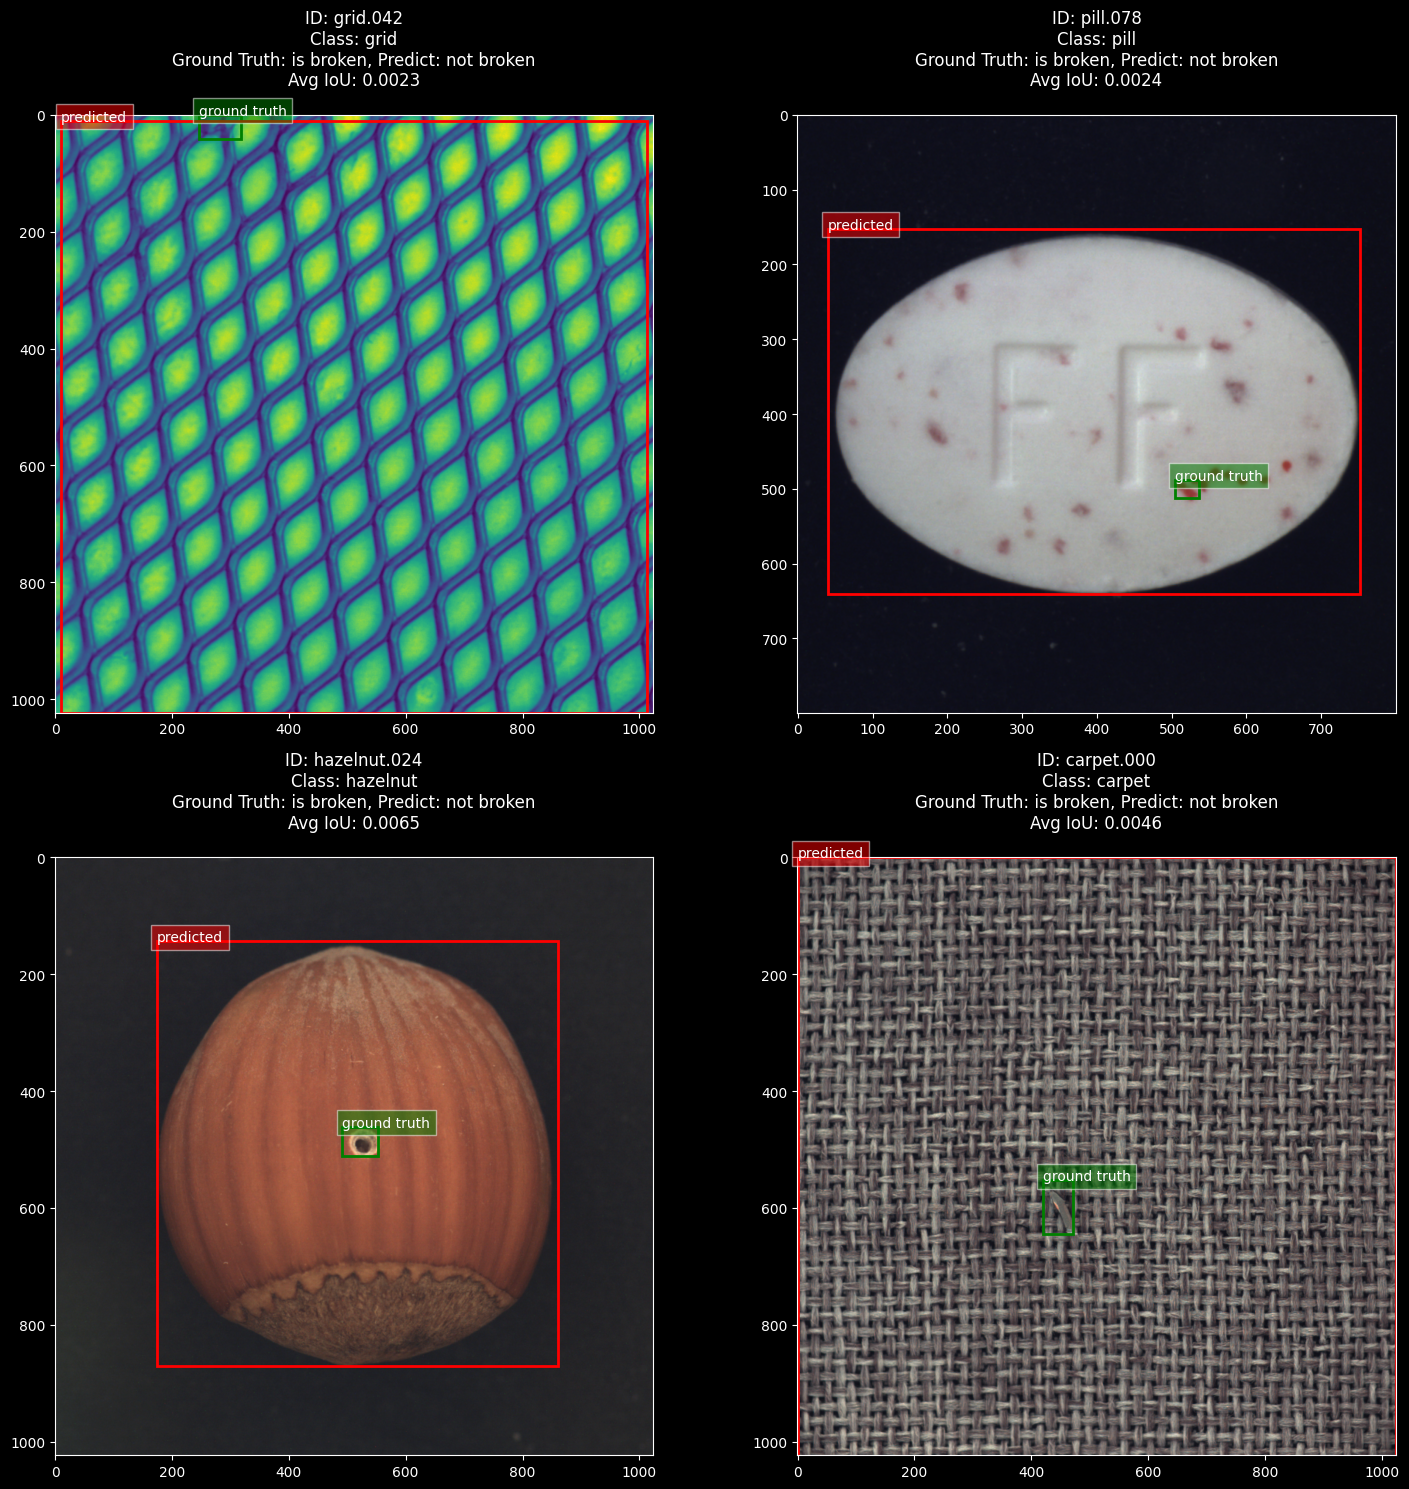

In [2]:
import json
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

def visualize_failed_cases_grid(json_path, image_base_path, img_id_list):
    """
    Visualizes failed cases in a 2x2 grid for a given list of img_ids.

    Args:
        json_path: Path to the JSON file containing failed case data.
        image_base_path: Base path to the MVTec AD dataset images.
        img_id_list: A list of img_ids to visualize.
    """
    with open(json_path, "r") as f:
        failed_cases = json.load(f)

    # Create a dictionary for faster lookup
    failed_cases_dict = {case["img_id"]: case for case in failed_cases}

    num_images = len(img_id_list)
    if num_images > 4:
        print("Warning: More than 4 img_ids provided. Only the first 4 will be visualized.")
        img_id_list = img_id_list[:4]
    
    num_rows = 2
    num_cols = 2

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 15))

    for i, img_id in enumerate(img_id_list):
        if img_id not in failed_cases_dict:
            print(f"Warning: img_id '{img_id}' not found in failed cases data.")
            continue

        case = failed_cases_dict[img_id]
        img_path = os.path.join(image_base_path, case["image_path"])
        try:
            img = Image.open(img_path)
        except FileNotFoundError:
            print(f"Image not found: {img_path}")
            continue

        row = i // num_cols
        col = i % num_cols
        ax = axes[row, col]
        ax.imshow(img)

        # Draw ground truth bbox
        if case["gt_bbox"]:
            gt_bbox = case["gt_bbox"]
            rect = patches.Rectangle(
                (gt_bbox[0], gt_bbox[1]),
                gt_bbox[2] - gt_bbox[0],
                gt_bbox[3] - gt_bbox[1],
                linewidth=2,
                edgecolor="g",
                facecolor="none",
            )
            ax.add_patch(rect)
            ax.text(
                gt_bbox[0],
                gt_bbox[1],
                "ground truth",
                bbox=dict(facecolor="green", alpha=0.5),
            )

        # Draw predicted bbox
        if case["pred_bbox"]:
            for pred_bbox in case["pred_bbox"]:
                rect = patches.Rectangle(
                    (pred_bbox[0], pred_bbox[1]),
                    pred_bbox[2] - pred_bbox[0],
                    pred_bbox[3] - pred_bbox[1],
                    linewidth=2,
                    edgecolor="r",
                    facecolor="none",
                )
                ax.add_patch(rect)
                ax.text(
                    pred_bbox[0],
                    pred_bbox[1],
                    "predicted",
                    bbox=dict(facecolor="red", alpha=0.5),
                )

        is_broken = "is broken" if case["is_broken"] == 1 else "not broken"
        pred_class = "is broken" if case["pred_class"] == 1 else "not broken"

        # plt.title(
        #     f"ID: {case['img_id']}\n"
        #     f"Class: {case['class']}\n"
        #     f"Ground Truth: {is_broken}, Predict: {pred_class}\n"
        #     f"Avg IoU: {case['avg_iou']:.4f}\n"
        #     f"Question: '[detection] a defect or not-defect object and return the bounding boxes and its label. If not, bound around the object.\n'"
        #     f"Answer: {case['answer']}"
            
        # )

        ax.set_title(
            f"ID: {case['img_id']}\n"
            f"Class: {case['class']}\n"
            f"Ground Truth: {is_broken}, Predict: {pred_class}\n"
            f"Avg IoU: {case['avg_iou']:.4f}\n"
        )

    # Hide unused subplots if less than 4 images
    for i in range(num_images, num_rows * num_cols):
      row = i // num_cols
      col = i % num_cols
      axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()


# Example usage:
json_file = "outputs/mvtech_ad_failed_cases.json"  # Path to the JSON file generated by the evaluation script
image_root_dir = "MVTEC_det/images"  #  Root directory of your MVTec AD dataset
img_ids_to_visualize = [
    "grid.042",
    "pill.078",
    "hazelnut.024",
    "carpet.000"
]

visualize_failed_cases_grid(json_file, image_root_dir, img_ids_to_visualize)